# Did Retail-Plus members order less often in Q2, in plain Python, SQL and pandas, and which tool would you sign?

**The solution twin.** Every placeholder is filled with its key, the notebook runs clean from a fresh kernel, and a line under each step says why the other letters fail.

> **The client asks.** "You did the tree in plain Python in Week 1, in SQL on Monday. Do it a
> third way now, and tell me honestly which tool you would pick for which job, and which one you
> would refuse for Finance's numbers."
>
> Kavya Nair, senior analyst, Kalpa Retail data team

The question all three tools answer is the branch of Week 1's revenue tree that moved:
**Retail-Plus orders per member, Q1 against Q2**, where a member counts in a quarter if they
ordered in it. Orders per member is orders divided by the members who ordered, the retail
dossier's frequency.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd
ENG = kit.engine()
print("connected to", kit.WAREHOUSE["dbname"])

connected to kalpa


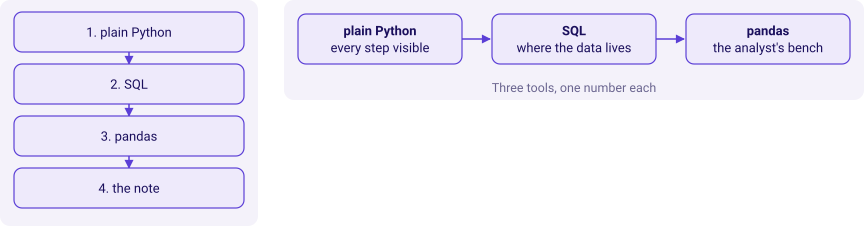

In [2]:
kit.side_by_side(
    kit.ladder(["plain Python", "SQL", "pandas", "the note"], show=False),
    kit.flow(["plain Python\nevery step visible", "SQL\nwhere the data lives",
              "pandas\nthe analyst's bench"], title="Three tools, one number each", show=False),
)

## Step 1. What does plain Python count, one row at a time?

The rows arrive as a list of dictionaries, the shape of Week 1's orders.

In [3]:
rows = kit.sql('''SELECT o.order_id, o.customer_id, o.quarter FROM orders o
                  JOIN customers c ON c.customer_id = o.customer_id
                  WHERE c.segment = 'Retail-Plus' ''')
orders_n = {"Q1": 0, "Q2": 0}
# TODO 1. What holds each quarter's members, so a member who orders twice counts once?
#   a) list()
#   b) 0
#   c) set()
#   d) dict()
seen = {"Q1": set(), "Q2": set()}
for r in rows:
    orders_n[r["quarter"]] += 1
    seen[r["quarter"]].add(r["customer_id"])
py = {qq: orders_n[qq] / len(seen[qq]) for qq in ("Q1", "Q2")}
print("plain Python:", {qq: round(v, 3) for qq, v in py.items()})

plain Python: {'Q1': 2.363, 'Q2': 1.842}


**Key 1c.** A list (a) and a dictionary (d) have no `.add`, and a list would also keep a member once per order; 0 (b) is a number, not a container. Only a set keeps each member once however many times they order.

In [4]:
kit.check("plain Python counts every Retail-Plus order", sum(orders_n.values()) == len(rows))
kit.check("each quarter's members are fewer than its orders", all(len(seen[qq]) < orders_n[qq] for qq in seen))
kit.table(["quarter", "orders", "members", "orders per member"],
          [(qq, orders_n[qq], len(seen[qq]), f"{py[qq]:.3f}") for qq in ("Q1", "Q2")], caption="Plain Python")

quarter,orders,members,orders per member
Q1,215,91,2.363
Q2,140,76,1.842


**Key 1c.** A list (a) and a dictionary (d) have no `.add`, and a list would also keep a member once per order; 0 (b) is a number, not a container. Only a set keeps each member once however many times they order.

## Step 2. Does SQL, where the data lives, give the same number?

In [5]:
# TODO 2. Which expression gives orders per member without Monday's integer-division trap?
#   a) orders / members
#   b) orders::numeric / members
#   c) members::numeric / orders
#   d) orders::numeric / (SELECT count(*) FROM customers)
# TODO 3. Which line keeps only Retail-Plus?
#   a) WHERE c.segment = 'Retail-Plus'
#   b) HAVING c.segment = 'Retail-Plus'
#   c) ORDER BY c.segment
#   d) WHERE c.segment <> 'Business'
SQL = '''WITH q AS (SELECT o.quarter, count(*) AS orders, count(DISTINCT o.customer_id) AS members
                    FROM orders o JOIN customers c ON c.customer_id = o.customer_id
                    WHERE c.segment = 'Retail-Plus'
                    GROUP BY o.quarter)
         SELECT quarter, orders, members, round(orders::numeric / members, 3) AS per_member
         FROM q ORDER BY quarter'''
sql_rows = kit.sql(SQL)
sq = {r["quarter"]: float(r["per_member"]) for r in sql_rows}
print("SQL:", sq)

SQL: {'Q1': 2.363, 'Q2': 1.842}


**Keys 2b and 3a.** 2a is Monday's trap: Postgres divides two whole numbers and returns 2 and 1. 2c turns the rate upside down. 2d divides by all 340 customers on the list, every segment, whoever ordered. 3b fails, because `HAVING` filters groups and the segment is not one of them; 3c only sorts; 3d keeps Retail-Core and the Students as well.

In [6]:
kit.check("SQL returns one row per quarter", [r["quarter"] for r in sql_rows] == ["Q1", "Q2"])
kit.check("SQL agrees with plain Python to three places", all(abs(sq[qq] - py[qq]) < 0.001 for qq in sq), sq)

**Keys 2b and 3a.** 2a is Monday's trap: Postgres divides two whole numbers and returns 2 and 1. 2c turns the rate upside down. 2d divides by all 340 customers on the list, every segment, whoever ordered. 3b fails, because `HAVING` filters groups and the segment is not one of them; 3c only sorts; 3d keeps Retail-Core and the Students as well.

## Step 3. Does pandas, the analyst's bench, give the same number?

In [7]:
df = pd.read_sql('''SELECT o.order_id, o.customer_id, o.quarter, c.segment FROM orders o
                    JOIN customers c ON c.customer_id = o.customer_id''', ENG)
rp = df[df["segment"] == "Retail-Plus"]
orders_pd = rp.groupby("quarter")["order_id"].count()
# TODO 4. Which method counts each quarter's members once each?
#   a) count
#   b) size
#   c) value_counts
#   d) nunique
members_pd = rp.groupby("quarter")["customer_id"].nunique()
pn = (orders_pd / members_pd).to_dict()
print("pandas:", {qq: round(v, 3) for qq, v in pn.items()})

pandas: {'Q1': 2.363, 'Q2': 1.842}


**Key 4d.** `count` (a) and `size` (b) count rows, which are orders, so the rate reads 1.000; `value_counts` (c) returns one count per member, a Series the division cannot line up with the quarters.

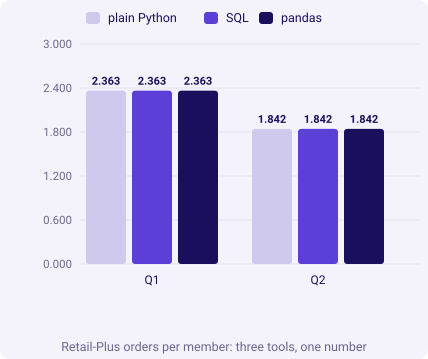

In [8]:
kit.check("pandas agrees with plain Python", all(abs(pn[qq] - py[qq]) < 1e-9 for qq in ("Q1", "Q2")))
kit.check("pandas agrees with SQL to three places", all(abs(pn[qq] - sq[qq]) < 0.001 for qq in ("Q1", "Q2")))
kit.columns(["Q1", "Q2"], [("plain Python", [round(py[qq], 3) for qq in ("Q1", "Q2")]),
                           ("SQL", [sq[qq] for qq in ("Q1", "Q2")]),
                           ("pandas", [round(pn[qq], 3) for qq in ("Q1", "Q2")])],
            fmt=lambda v: f"{v:.3f}", title="Retail-Plus orders per member: three tools, one number")

**Key 4d.** `count` (a) and `size` (b) count rows, which are orders, so the rate reads 1.000; `value_counts` (c) returns one count per member, a Series the division cannot line up with the quarters.

## Step 4. Which tool would you sign for each job, sized on what each route moved?

The three agree, so the choice is about who has to trust, rerun or audit the number, and about
what each route cost. The cell counts the rows each route moved out of the warehouse.

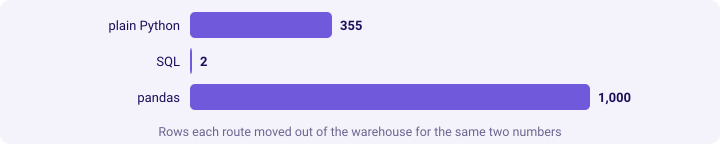

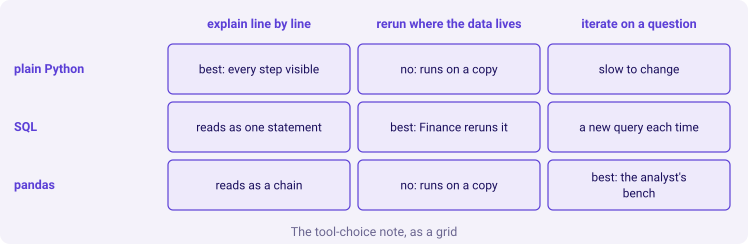

In [9]:
moved = [("plain Python", len(rows)), ("SQL", len(sql_rows)), ("pandas", len(df))]
kit.bars(moved, title="Rows each route moved out of the warehouse for the same two numbers")
# TODO 5. Where should a number Finance reruns every Monday be computed?
#   a) "a pandas notebook on the analyst's machine"
#   b) "a plain Python loop"
#   c) "a SQL query in the warehouse"
#   d) "a CSV export refreshed every Monday"
finance_home = "a SQL query in the warehouse"
kit.matrix(["plain Python", "SQL", "pandas"], ["explain line by line", "rerun where the data lives", "iterate on a question"],
           [["best: every step visible", "no: runs on a copy", "slow to change"],
            ["reads as one statement", "best: Finance reruns it", "a new query each time"],
            ["reads as a chain", "no: runs on a copy", "best: the analyst's bench"]],
           title="The tool-choice note, as a grid")

**Key 5c.** Finance's number lives where Finance can rerun and audit it, in the warehouse, as a query that moves only its answer. A notebook (a) and a loop (b) run on a copy on one machine; an export (d) is a copy that ages from the moment it is written.

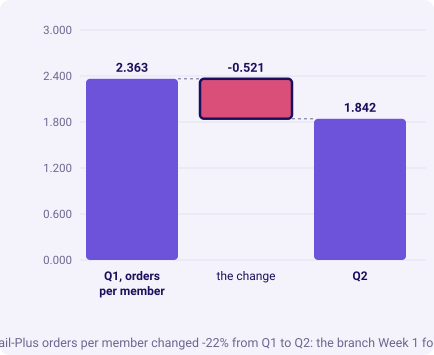

In [10]:
kit.check("the three tools agree on both quarters",
          all(abs(py[qq] - pn[qq]) < 1e-9 and abs(py[qq] - sq[qq]) < 0.001 for qq in ("Q1", "Q2")))
kit.check("SQL moved the fewest rows", min(moved, key=lambda m: m[1])[0] == "SQL")
kit.check("a home was chosen for Finance's number", isinstance(finance_home, str) and len(finance_home) > 0)
fall = pn["Q2"] / pn["Q1"] - 1
kit.bridge(("Q1, orders per member", round(pn["Q1"], 3)), [("the change", round(pn["Q2"] - pn["Q1"], 3))],
           end_label="Q2", fmt=lambda v: f"{v:.3f}", lit=(0,),
           title=f"Retail-Plus orders per member changed {fall:.0%} from Q1 to Q2: the branch Week 1 found")
kit.check_summary()

**Key 5c.** Finance's number lives where Finance can rerun and audit it, in the warehouse, as a query that moves only its answer. A notebook (a) and a loop (b) run on a copy on one machine; an export (d) is a copy that ages from the moment it is written.

**Post:** your five letters, and your tool-choice note in the brief's format: one line per tool
with the job it owns and the rows it moved, and the tool you would refuse for Finance's numbers,
with the reason.